In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_pad_logs(file_path, arch_name):
    with open(file_path, 'r') as f:
        data = json.load(f)
    df = pd.json_normalize(data)
    df['architecture'] = arch_name
    
    if len(df) == 19:
        empty_row = pd.DataFrame(np.nan, index=[14], columns=df.columns)
        empty_row['architecture'] = arch_name
        df = pd.concat([df.iloc[:14], empty_row, df.iloc[14:]]).reset_index(drop=True)
    return df

# Load all 4 architectures
baseline_df = load_and_pad_logs('logs/telemetry_baseline_mistral-small3.2.json', 'Baseline')
spear_l31_df = load_and_pad_logs('logs/telemetry_SPEAR_mistral-small3.2_llama3.1.json', 'SPEAR (L3.1 Router)')
spear_l32_df = load_and_pad_logs('logs/telemetry_SPEAR_mistral-small3.2_llama3.2.json', 'SPEAR (L3.2 Router)')
spear_phi_df = load_and_pad_logs('logs/telemetry_SPEAR_mistral-small3.2_phi3.5-3.8b.json', 'SPEAR (Phi-3.5 Router)')

df = pd.concat([baseline_df, spear_l31_df, spear_l32_df, spear_phi_df], ignore_index=True)

# Compute Metrics
critic_cols = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]
df['avg_critic_score'] = df[critic_cols].mean(axis=1)
df['score_per_1k'] = (df['avg_critic_score'] / df['total_tokens']) * 1000

# Color Palettes
arch_colors = {
    'Baseline': '#3498db',               # Blue
    'SPEAR (L3.1 Router)': '#e74c3c',    # Red
    'SPEAR (L3.2 Router)': '#2ecc71',    # Green
    'SPEAR (Phi-3.5 Router)': '#9b59b6'  # Purple
}

/tmp/ipykernel_51268/2319927020.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


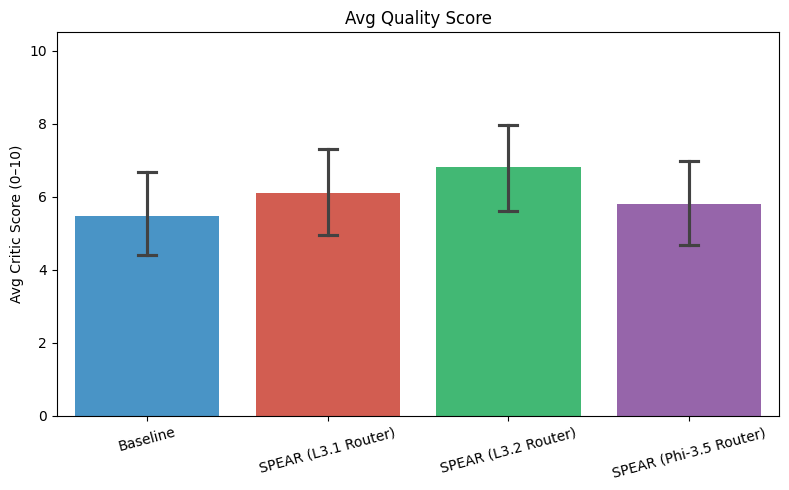

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x='architecture',
    y='avg_critic_score',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

ax.set_title('Avg Quality Score')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

/tmp/ipykernel_51268/257085720.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


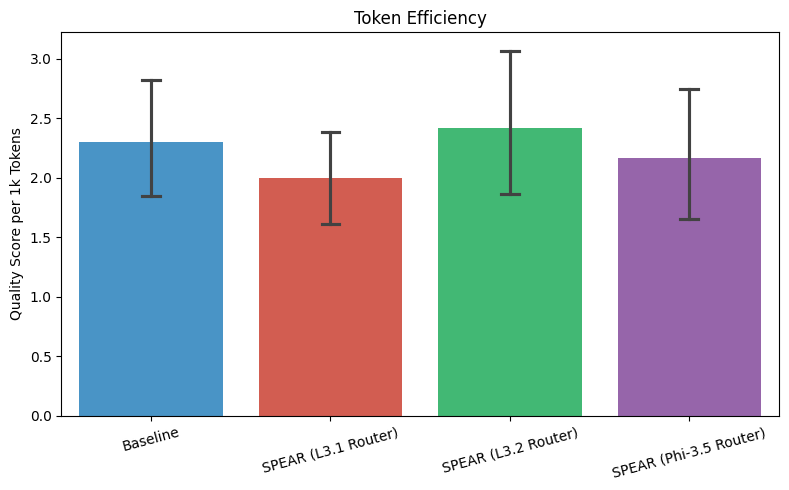

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x='architecture',
    y='score_per_1k',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

ax.set_title('Token Efficiency')
ax.set_xlabel('')
ax.set_ylabel('Quality Score per 1k Tokens')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

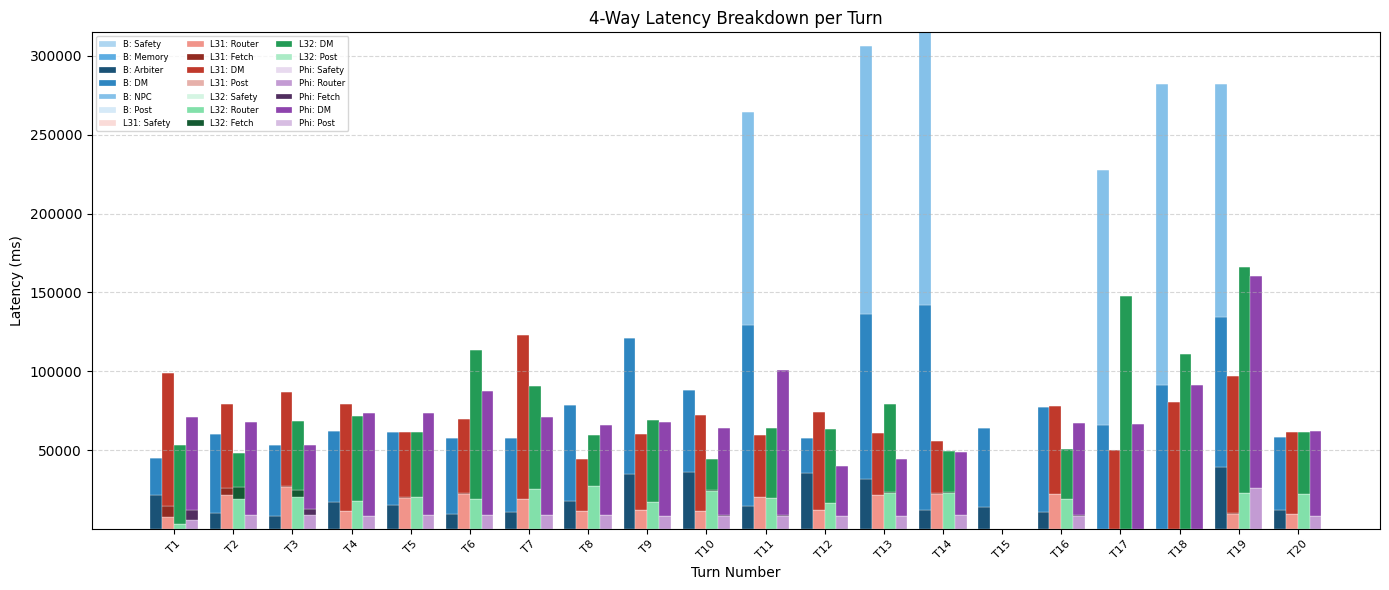

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

def extract_spear_comps(sub_df):
    return pd.DataFrame({
        'Safety':  sub_df['latency_breakdown.safety_filter_ms'].fillna(0),
        'Router':  sub_df['latency_breakdown.router_ms'].fillna(0),
        'Fetch':   sub_df['latency_breakdown.parallel_fetch_ms'].fillna(0),
        'DM':      sub_df['latency_breakdown.dm_ms'].fillna(0),
        'Post':    sub_df['latency_breakdown.post_processing_ms'].fillna(0),
    })

base_comps = pd.DataFrame({
    'B: Safety':  baseline_df['latency_breakdown.safety_ms'].fillna(0),
    'B: Memory':  baseline_df['latency_breakdown.memory_ms'].fillna(0),
    'B: Arbiter': baseline_df['latency_breakdown.arbiter_ms'].fillna(0),
    'B: DM':      baseline_df['latency_breakdown.dm_ms'].fillna(0),
    'B: NPC':     baseline_df['latency_breakdown.npc_agent_ms'].fillna(0),
    'B: Post':    baseline_df['latency_breakdown.post_processing_ms'].fillna(0),
})

l31_comps = extract_spear_comps(spear_l31_df)
l32_comps = extract_spear_comps(spear_l32_df)
phi_comps = extract_spear_comps(spear_phi_df)

c_base = ['#AED6F1', '#5DADE2', '#1A5276', '#2E86C1', '#85C1E9', '#D6EAF8']
c_l31  = ['#FADBD8', '#F1948A', '#922B21', '#C0392B', '#E6B0AA']
c_l32  = ['#D5F5E3', '#82E0AA', '#145A32', '#239B56', '#ABEBC6']
c_phi  = ['#E8DAEF', '#C39BD3', '#512E5F', '#8E44AD', '#D7BDE2']

x = np.arange(20)
width = 0.2

def plot_stack(ax, comps, offset, colors, prefix):
    bottom = np.zeros(20)
    for idx, col in enumerate(comps.columns):
        label = f"{prefix}: {col}" if "B:" not in col else col
        ax.bar(
            x + offset,
            comps[col],
            width,
            label=label,
            bottom=bottom,
            color=colors[idx],
            edgecolor='white',
            linewidth=0.2
        )
        bottom += comps[col].values

plot_stack(ax, base_comps, -0.3, c_base, "Base")
plot_stack(ax, l31_comps,  -0.1, c_l31,  "L31")
plot_stack(ax, l32_comps,   0.1, c_l32,  "L32")
plot_stack(ax, phi_comps,   0.3, c_phi,  "Phi")

ax.set_title('4-Way Latency Breakdown per Turn')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(20)], rotation=45, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(loc='upper left', fontsize=6, ncol=3)

plt.tight_layout()
plt.show()

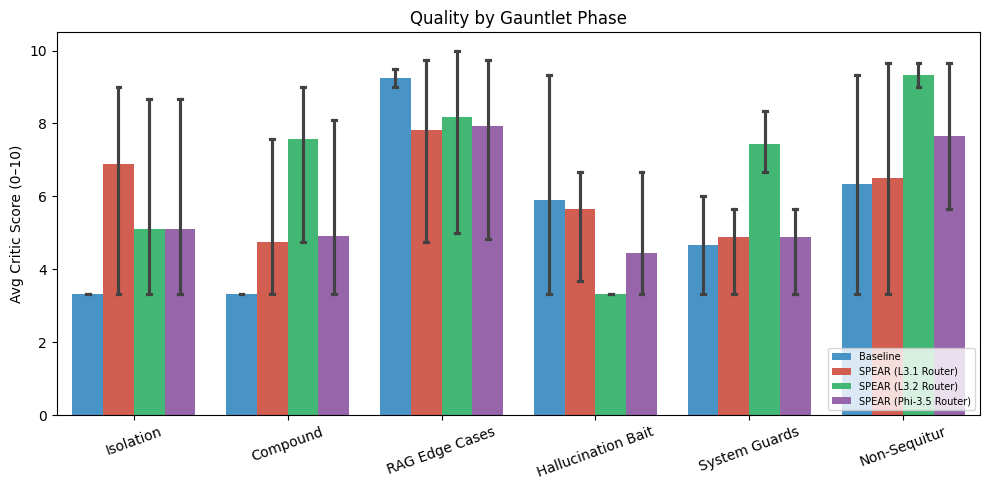

In [5]:
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]

df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    x='phase',
    y='avg_critic_score',
    hue='architecture',
    data=df,
    palette=arch_colors,
    capsize=0.1,
    ax=ax
)

ax.set_title('Quality by Gauntlet Phase')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=7, loc='lower right')

plt.tight_layout()
plt.show()

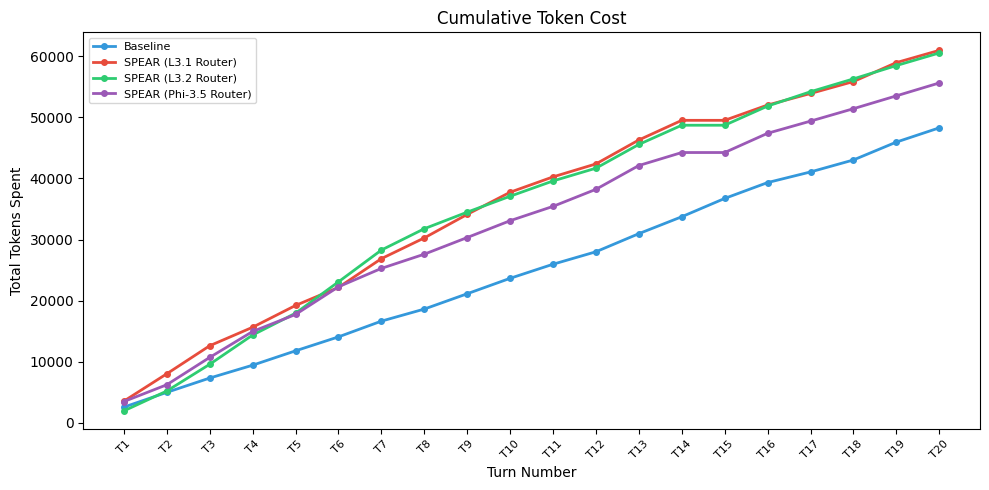

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(20)

for arch, color in arch_colors.items():
    subset = df[df['architecture'] == arch].reset_index(drop=True)
    cum_tokens = subset['total_tokens'].fillna(0).cumsum()
    ax.plot(
        range(20),
        cum_tokens,
        color=color,
        linewidth=2,
        label=arch,
        marker='o',
        markersize=4
    )

ax.set_title('Cumulative Token Cost')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Total Tokens Spent')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(20)], rotation=45, fontsize=8)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

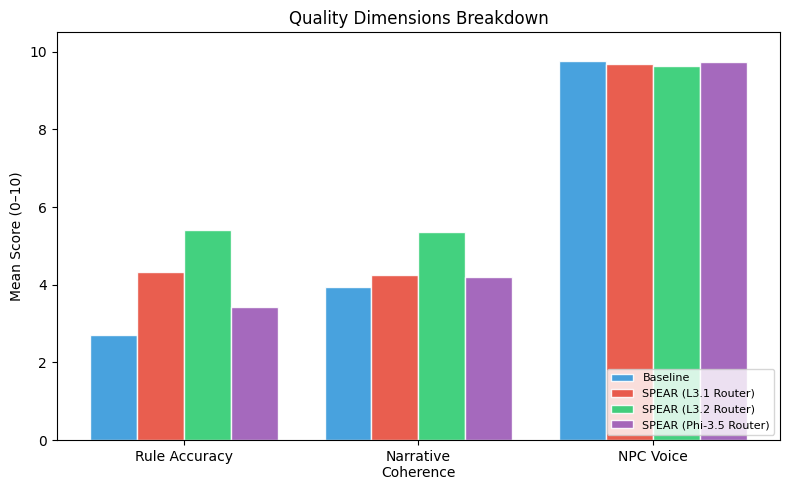

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

dims = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]

dim_labels = ['Rule Accuracy', 'Narrative\nCoherence', 'NPC Voice']
x_dim = np.arange(len(dims))
width_dim = 0.2

for i, (arch, color) in enumerate(arch_colors.items()):
    offset = (i - 1.5) * width_dim
    means = [df[df['architecture'] == arch][d].mean() for d in dims]
    
    ax.bar(
        x_dim + offset,
        means,
        width_dim,
        label=arch,
        color=color,
        alpha=0.9,
        edgecolor='white'
    )

ax.set_title('Quality Dimensions Breakdown')
ax.set_ylabel('Mean Score (0–10)')
ax.set_xticks(x_dim)
ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_51268/2791344277.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='avg_critic_score', data=df, palette=arch_colors, capsize=0.1, ax=ax)
/tmp/ipykernel_51268/2791344277.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='architecture', y='score_per_1k', data=df, palette=arch_colors, capsize=0.1, ax=ax)


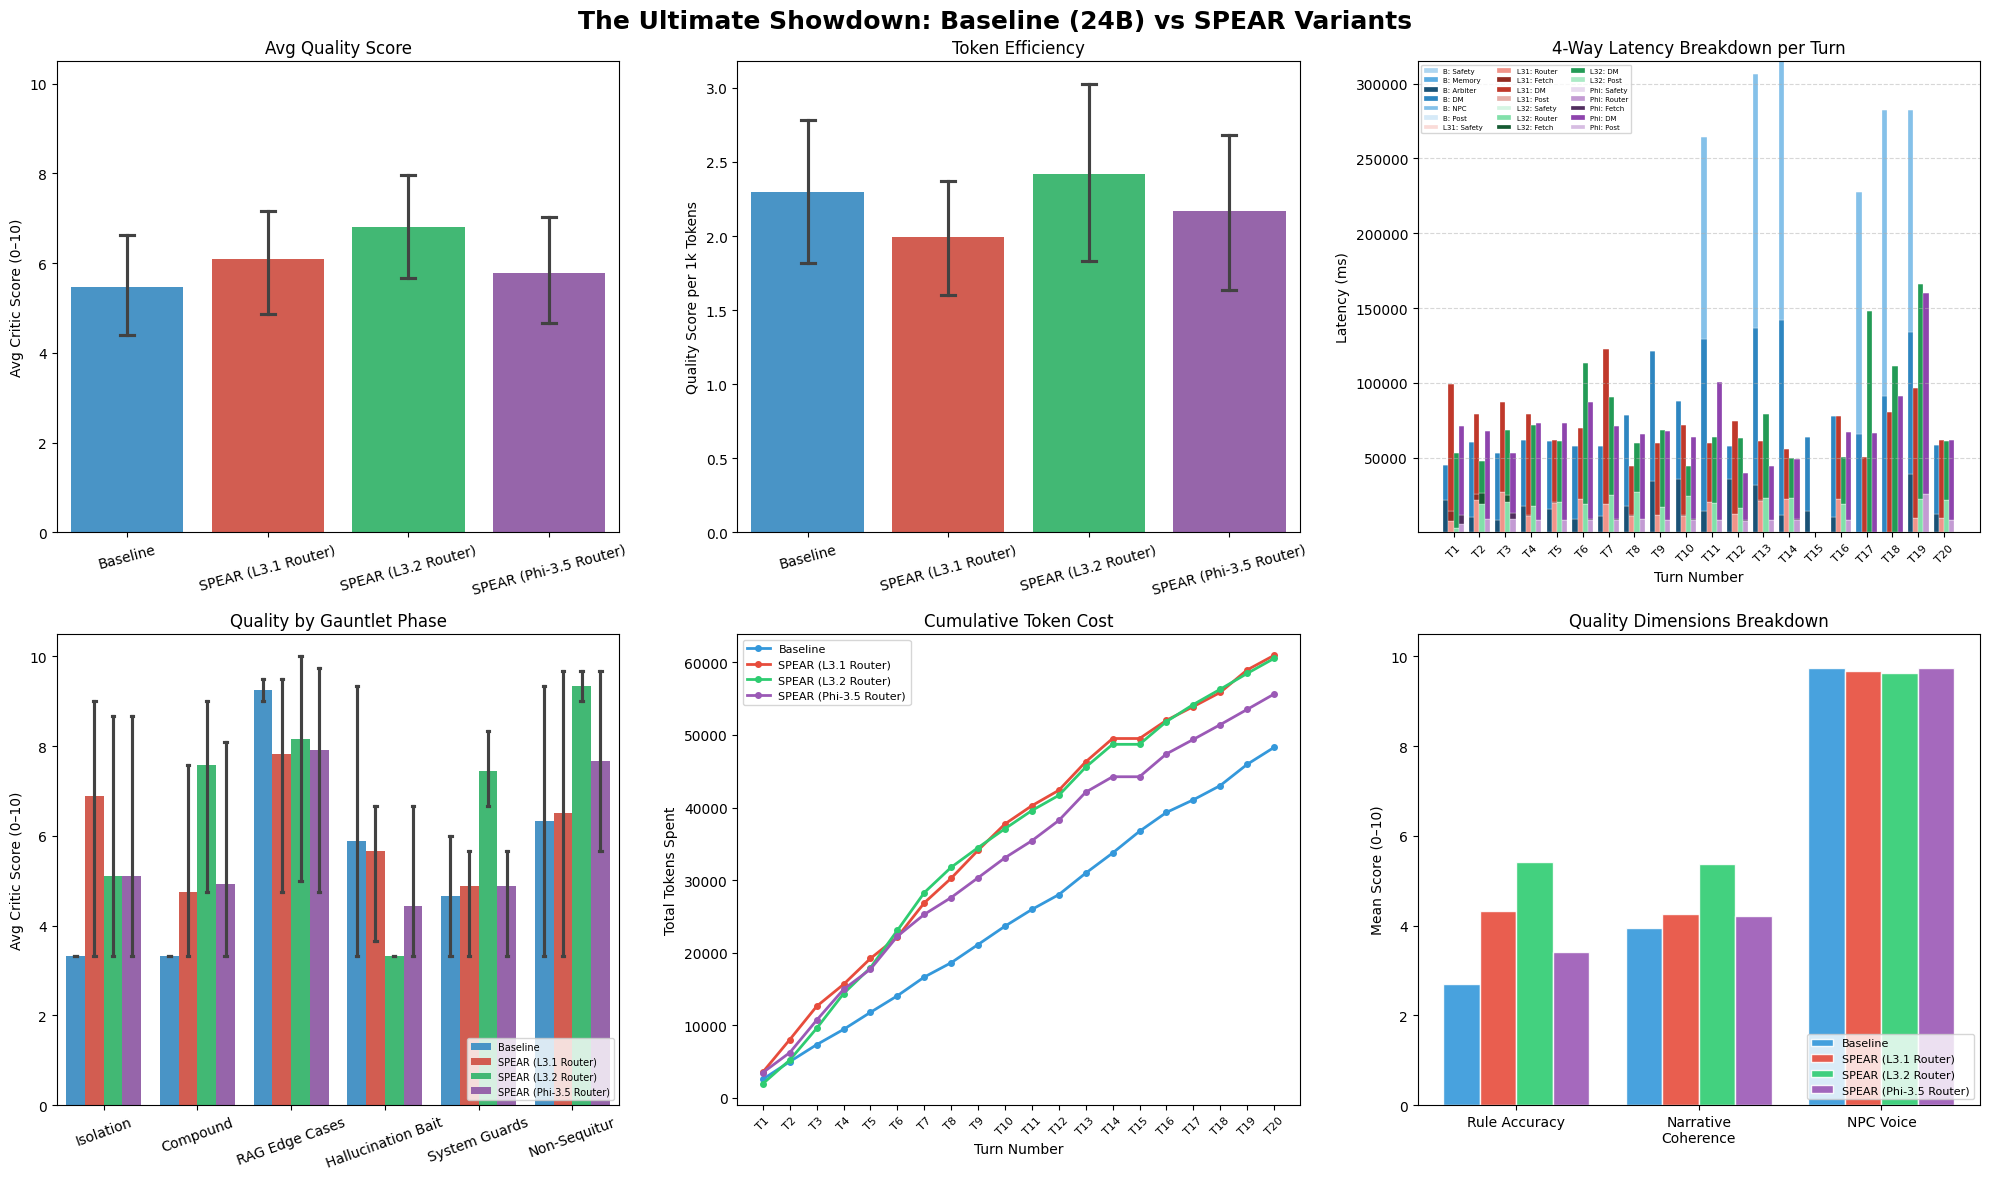

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("The Ultimate Showdown: Baseline (24B) vs SPEAR Variants", fontsize=18, fontweight='bold')

# --- Avg Quality Score ---
ax = axes[0, 0]
sns.barplot(x='architecture', y='avg_critic_score', data=df, palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Avg Quality Score')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=15)

# --- Token Efficiency ---
ax = axes[0, 1]
sns.barplot(x='architecture', y='score_per_1k', data=df, palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Token Efficiency')
ax.set_xlabel('')
ax.set_ylabel('Quality Score per 1k Tokens')
ax.tick_params(axis='x', rotation=15)

# --- 4-Way Latency Breakdown per Turn ---
ax = axes[0, 2]

def extract_spear_comps(sub_df):
    return pd.DataFrame({
        'Safety':  sub_df['latency_breakdown.safety_filter_ms'].fillna(0),
        'Router':  sub_df['latency_breakdown.router_ms'].fillna(0),
        'Fetch':   sub_df['latency_breakdown.parallel_fetch_ms'].fillna(0),
        'DM':      sub_df['latency_breakdown.dm_ms'].fillna(0),
        'Post':    sub_df['latency_breakdown.post_processing_ms'].fillna(0),
    })

base_comps = pd.DataFrame({
    'B: Safety':  baseline_df['latency_breakdown.safety_ms'].fillna(0),
    'B: Memory':  baseline_df['latency_breakdown.memory_ms'].fillna(0),
    'B: Arbiter': baseline_df['latency_breakdown.arbiter_ms'].fillna(0),
    'B: DM':      baseline_df['latency_breakdown.dm_ms'].fillna(0),
    'B: NPC':     baseline_df['latency_breakdown.npc_agent_ms'].fillna(0),
    'B: Post':    baseline_df['latency_breakdown.post_processing_ms'].fillna(0),
})

l31_comps = extract_spear_comps(spear_l31_df)
l32_comps = extract_spear_comps(spear_l32_df)
phi_comps = extract_spear_comps(spear_phi_df)

# Specific Stack Colors to match their architectures
c_base = ['#AED6F1', '#5DADE2', '#1A5276', '#2E86C1', '#85C1E9', '#D6EAF8']
c_l31  = ['#FADBD8', '#F1948A', '#922B21', '#C0392B', '#E6B0AA']
c_l32  = ['#D5F5E3', '#82E0AA', '#145A32', '#239B56', '#ABEBC6']
c_phi  = ['#E8DAEF', '#C39BD3', '#512E5F', '#8E44AD', '#D7BDE2']

x = np.arange(20)
width = 0.2

def plot_stack(ax, comps, offset, colors, prefix):
    bottom = np.zeros(20)
    for idx, col in enumerate(comps.columns):
        label = f"{prefix}: {col}" if "B:" not in col else col
        ax.bar(x + offset, comps[col], width, label=label, bottom=bottom, 
               color=colors[idx], edgecolor='white', linewidth=0.2)
        bottom += comps[col].values

# Shift the bars so they lock together over the tick mark
plot_stack(ax, base_comps, -0.3, c_base, "Base")
plot_stack(ax, l31_comps,  -0.1, c_l31,  "L31")
plot_stack(ax, l32_comps,   0.1, c_l32,  "L32")
plot_stack(ax, phi_comps,   0.3, c_phi,  "Phi")

ax.set_title('4-Way Latency Breakdown per Turn')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Latency (ms)')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(20)], rotation=45, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Compress massive legend into 3 columns
ax.legend(loc='upper left', fontsize=5, ncol=3)

# --- Quality by Gauntlet Phase ---
phase_labels = [
    'Isolation', 'Isolation', 'Isolation',
    'Compound', 'Compound', 'Compound', 'Compound',
    'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases', 'RAG Edge Cases',
    'Hallucination Bait', 'Hallucination Bait', 'Hallucination Bait',
    'System Guards', 'System Guards', 'System Guards', 'System Guards',
    'Non-Sequitur', 'Non-Sequitur'
]

df['phase'] = df.groupby('architecture').cumcount().map(dict(enumerate(phase_labels)))

ax = axes[1, 0]
sns.barplot(x='phase', y='avg_critic_score', hue='architecture', data=df, palette=arch_colors, capsize=0.1, ax=ax)
ax.set_title('Quality by Gauntlet Phase')
ax.set_xlabel('')
ax.set_ylabel('Avg Critic Score (0–10)')
ax.set_ylim(0, 10.5)
ax.tick_params(axis='x', rotation=20)
ax.legend(fontsize=7, loc='lower right')

# --- Cumulative Token Cost ---
ax = axes[1, 1]
# We sort by architecture first, then by turn index to ensure smooth cumulative sums over the padded NaNs
for arch, color in arch_colors.items():
    subset = df[df['architecture'] == arch].reset_index(drop=True)
    # Forward fill the missing total_tokens from the NaN padding so the line stays flat for that turn
    cum_tokens = subset['total_tokens'].fillna(0).cumsum()
    ax.plot(range(20), cum_tokens, color=color, linewidth=2, label=arch, marker='o', markersize=4)

ax.set_title('Cumulative Token Cost')
ax.set_xlabel('Turn Number')
ax.set_ylabel('Total Tokens Spent')
ax.set_xticks(x)
ax.set_xticklabels([f"T{i+1}" for i in range(20)], rotation=45, fontsize=8)
ax.legend(fontsize=8)

# --- Quality Score Dimensions Side by Side ---
ax = axes[1, 2]
dims = [
    'async_critic_scores.rule_accuracy',
    'async_critic_scores.narrative_coherence',
    'async_critic_scores.npc_voice_consistency'
]
dim_labels = ['Rule Accuracy', 'Narrative\nCoherence', 'NPC Voice']
x_dim = np.arange(len(dims))
width_dim = 0.2

for i, (arch, color) in enumerate(arch_colors.items()):
    # Calculate offset based on index (0, 1, 2, 3)
    offset = (i - 1.5) * width_dim
    means = [df[df['architecture'] == arch][d].mean() for d in dims]
    ax.bar(x_dim + offset, means, width_dim, label=arch, color=color, alpha=0.9, edgecolor='white')

ax.set_title('Quality Dimensions Breakdown')
ax.set_ylabel('Mean Score (0–10)')
ax.set_xticks(x_dim)
ax.set_xticklabels(dim_labels, fontsize=10)
ax.set_ylim(0, 10.5)
ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()

# Save the plot
plot_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'plot')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'ultimate_4way_showdown.png'), dpi=200, bbox_inches='tight')
plt.show()